In [3]:
!pip install torch torchvision numpy opencv-python matplotlib scipy


Defaulting to user installation because normal site-packages is not writeable


In [5]:
import os

# 1. 填入你解压出来的文件夹名字
project_folder_name = 'Project_Folder'  # <--- 请根据第一步看到的打印结果修改这里的名字！

# 2. 检查一下是否存在，如果存在就进入
if os.path.exists(project_folder_name):
    os.chdir(project_folder_name)
    print(f"成功进入文件夹: {os.getcwd()}")
else:
    print(f"没找到 {project_folder_name}，请检查第一步打印的文件列表。")

# 3. 再次确认 utils 是否在眼前
if 'utils' in os.listdir():
    print("太棒了！找到了 utils 文件夹，现在可以运行 import 了。")
else:
    print("还是没找到 utils，请检查你的压缩包结构。")

成功进入文件夹: /home/tic041/teams/project-team-56/Tiancheng/Project_Folder
太棒了！找到了 utils 文件夹，现在可以运行 import 了。


In [9]:
import os
import torch
import numpy as np
import logging
from collections import OrderedDict

# 导入你上传的模块 (确保路径正确)
from utils import utils_logger
from utils import utils_model
from utils import utils_image as util
from models.network_dncnn import DnCNN as net

# ==========================================
# 1. 适配 DataHub：使用类来定义参数，而不是 argparse
# ==========================================
class Config:
    def __init__(self):
        self.model_name = 'dncnn_25'       # 你想用的模型: dncnn_15, dncnn_25, dncnn_50
        self.testset_name = 'BSD68'        # 测试集文件夹名: set12, bsd68
        self.noise_level_img = 25          # 噪声水平: 15, 25, 50 (要与模型匹配)
        self.x8 = False                    # 是否使用 x8 增强
        self.show_img = True               # 是否在 Notebook 中显示图片
        self.model_pool = 'model_zoo'      # 模型文件夹路径
        self.testsets = 'testsets'         # 测试集根目录
        self.results = 'results'           # 结果保存目录
        self.need_degradation = True       # 是否需要加噪 (如果输入是干净图则设为True)
        self.task_current = 'dn'           # fixed
        self.sf = 1                        # fixed

# 初始化参数
args = Config()

# ==========================================
# 2. 运行主逻辑 (主要逻辑与原 main() 相同，微调显示部分)
# ==========================================

# 检查是否使用 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on device: {device}")

# 路径设置
if 'color' in args.model_name:
    n_channels = 3
else:
    n_channels = 1

if args.model_name in ['dncnn_gray_blind', 'dncnn_color_blind', 'dncnn3']:
    nb = 20
else:
    nb = 17

result_name = args.testset_name + '_' + args.model_name
border = args.sf if args.task_current == 'sr' else 0
model_path = os.path.join(args.model_pool, args.model_name+'.pth')

# 检查模型文件是否存在
if not os.path.exists(model_path):
    print(f"Error: Model not found at {model_path}. Please verify 'model_zoo' folder.")
else:
    # 设置路径
    L_path = os.path.join(args.testsets, args.testset_name)
    H_path = L_path
    E_path = os.path.join(args.results, result_name)
    util.mkdir(E_path)

    if H_path == L_path:
        args.need_degradation = True

    # 日志设置 (简化，直接打印)
    print(f"Result Path: {E_path}")

    # 加载模型
    model = net(in_nc=n_channels, out_nc=n_channels, nc=64, nb=nb, act_mode='R')
    model.load_state_dict(torch.load(model_path, map_location=device), strict=True)
    model.eval()
    for k, v in model.named_parameters():
        v.requires_grad = False
    model = model.to(device)
    print(f"Model loaded: {model_path}")

    # 处理图片
    L_paths = util.get_image_paths(L_path)
    
    if len(L_paths) == 0:
        print(f"No images found in {L_path}")
    
    for idx, img in enumerate(L_paths):
        # (1) 读取图片
        img_name, ext = os.path.splitext(os.path.basename(img))
        img_L = util.imread_uint(img, n_channels=n_channels)
        img_L = util.uint2single(img_L)

        # (2) 加噪
        if args.need_degradation:
            np.random.seed(seed=0)
            img_L += np.random.normal(0, args.noise_level_img/255., img_L.shape)

        # DataHub 中显示图片通常用 matplotlib
        # 这里跳过 cv2.imshow，避免在云端报错

        img_L_tensor = util.single2tensor4(img_L)
        img_L_tensor = img_L_tensor.to(device)

        # (3) 推理
        if not args.x8:
            img_E = model(img_L_tensor)
        else:
            img_E = utils_model.test_mode(model, img_L_tensor, mode=3)

        img_E = util.tensor2uint(img_E)

        # (4) 计算指标并保存
        img_H = util.imread_uint(img, n_channels=n_channels)
        img_H = img_H.squeeze()
        
        psnr = util.calculate_psnr(img_E, img_H, border=border)
        ssim = util.calculate_ssim(img_E, img_H, border=border)
        
        print(f'{img_name+ext} - PSNR: {psnr:.2f} dB; SSIM: {ssim:.4f}')
        
        util.imsave(img_E, os.path.join(E_path, img_name+ext))

    print("Done! Results saved to:", E_path)
    

Running on device: cuda
Result Path: results/BSD68_dncnn_25
Model loaded: model_zoo/dncnn_25.pth
0000.png - PSNR: 38.27 dB; SSIM: 0.9645
0001.png - PSNR: 28.44 dB; SSIM: 0.7846
0002.png - PSNR: 32.97 dB; SSIM: 0.8669
0003.png - PSNR: 28.65 dB; SSIM: 0.7979
0004.png - PSNR: 28.16 dB; SSIM: 0.7980
0005.png - PSNR: 29.50 dB; SSIM: 0.7883
0006.png - PSNR: 30.10 dB; SSIM: 0.9158
0007.png - PSNR: 24.80 dB; SSIM: 0.8444
0008.png - PSNR: 25.96 dB; SSIM: 0.7294
0009.png - PSNR: 30.28 dB; SSIM: 0.8725
0010.png - PSNR: 30.16 dB; SSIM: 0.8644
0011.png - PSNR: 30.73 dB; SSIM: 0.8500
0012.png - PSNR: 27.68 dB; SSIM: 0.8186
0013.png - PSNR: 33.05 dB; SSIM: 0.8978
0014.png - PSNR: 28.75 dB; SSIM: 0.8230
0015.png - PSNR: 26.29 dB; SSIM: 0.7646
0016.png - PSNR: 29.13 dB; SSIM: 0.8387
0017.png - PSNR: 29.83 dB; SSIM: 0.8201
0018.png - PSNR: 29.16 dB; SSIM: 0.8775
0019.png - PSNR: 29.61 dB; SSIM: 0.8214
0020.png - PSNR: 30.93 dB; SSIM: 0.8541
0021.png - PSNR: 27.31 dB; SSIM: 0.7843
0022.png - PSNR: 28.22 

Running on: cuda
Loading DnCNN-25 model...
Found 68 images in BSD68.

Processing BSD68 with Sigma=25...


100%|██████████| 68/68 [00:03<00:00, 18.67it/s]



##################################################
 FINAL RESULTS (BSD68, Sigma=25)
##################################################
Average Noisy PSNR:    20.48 dB
Average Denoised PSNR: 28.88 dB
Average Denoised SSIM: 0.8200
Generating comparison plot for the first image...
Visualization saved to: results/BSD68_dncnn_25/dncnn_summary_sigma25_first_image.png


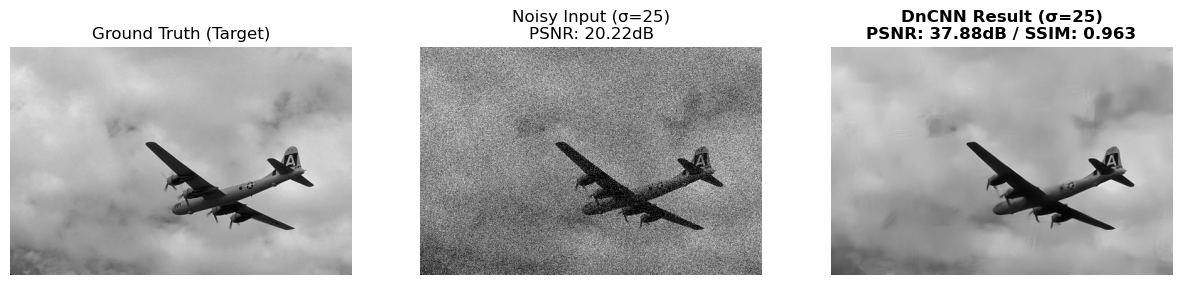

In [17]:
import os
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import OrderedDict
from tqdm import tqdm

# 注意：这些导入依赖于你的项目结构：utils/utils_xxx.py 和 models/network_dncnn.py
# 如果报错 ModuleNotFoundError: No module named 'utils'，你需要先解决路径问题。
from models.network_dncnn import DnCNN as net
# 假设 util 是 utils_image，utils_model 在 utils 文件夹内
from utils import utils_image as util
from utils import utils_model 

# ============================
# 1. 配置参数
# ============================
class Config:
    def __init__(self):
        self.model_name = 'dncnn_25'       
        self.testset_name = 'BSD68'        
        self.noise_level_img = 25          
        self.model_pool = 'model_zoo'      
        self.testsets = 'testsets'         
        self.results = 'results'           
        self.task_current = 'dn'           
        self.sf = 1                        
        self.BSD68_PATH = os.path.join(self.testsets, self.testset_name)

args = Config()
SIGMA = args.noise_level_img

# ============================
# 2. 定义 DnCNN 网络结构 (保持原结构)
# ============================
# 假设 net(in_nc, out_nc, nc, nb, act_mode) 是你导入的 DnCNN 类的签名。
# 这里不需要重复完整的 DnCNN class 定义，因为它依赖于外部文件。
# 为了代码完整性，我们依赖于 'from models.network_dncnn import DnCNN as net' 的导入成功。
pass 

# ============================
# 3. 主逻辑
# ============================
if __name__ == "__main__":
    
    # --- 准备环境 ---
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Running on: {device}")
    
    model_path = os.path.join(args.model_pool, args.model_name+'.pth')
    if not os.path.exists(model_path):
        print(f"Error: 模型文件不存在 {model_path}")
        exit()

    # --- 加载模型 ---
    print(f"Loading DnCNN-{SIGMA} model...")
    n_channels = 1
    nb = 17 # 假设 dncnn_25 是 17 层
    
    model = net(in_nc=n_channels, out_nc=n_channels, nc=64, nb=nb, act_mode='R')
    model.load_state_dict(torch.load(model_path, map_location=device), strict=True)
    model.eval()
    for k, v in model.named_parameters(): v.requires_grad = False
    model = model.to(device)

    # --- 路径设置 ---
    E_path = os.path.join(args.results, args.testset_name + '_' + args.model_name)
    util.mkdir(E_path)
    
    # --- 获取数据 ---
    try:
        # L_paths 是 clean images 的路径列表
        image_files = util.get_image_paths(args.BSD68_PATH) 
        print(f"Found {len(image_files)} images in BSD68.")
    except Exception as e:
        print(f"Error getting image paths: {e}")
        exit()

    # --- 循环测试变量 ---
    psnr_noisy_list = []
    psnr_denoised_list = []
    ssim_denoised_list = []
    visual_data = {} # 存储第一张图片的数据

    print(f"\nProcessing BSD68 with Sigma={SIGMA}...")
    
    for idx, img_path in enumerate(tqdm(image_files)):
        
        # 1. 读取真值 (GT)
        # util.imread_uint 返回 uint8 [0-255]，形状通常是 (H, W, 1) 或 (H, W)
        img_gt_uint = util.imread_uint(img_path, n_channels=n_channels)
        img_gt_single = util.uint2single(img_gt_uint) # float32 [0-1]
        
        # 2. 加噪 (Synthetic Noise)
        np.random.seed(42 + idx) 
        noise = np.random.normal(0, SIGMA/255.0, img_gt_single.shape)
        img_L_single = np.clip(img_gt_single + noise, 0, 1) # float32 [0-1]
        img_L_uint = util.single2uint(img_L_single) # uint8 [0-255]
        
        # 3. 推理 (Denoise)
        img_L_tensor = util.single2tensor4(img_L_single).to(device)
        with torch.no_grad():
            img_E_tensor = model(img_L_tensor) 
        img_denoised = util.tensor2uint(img_E_tensor) # uint8 [0-255]
        
        # 4. 计算指标 (核心修正：所有输入都必须是 (H, W) 形状)
        img_gt_sq = img_gt_uint.squeeze()
        img_L_sq = img_L_uint.squeeze()
        img_E_sq = img_denoised.squeeze()
        
        p_n = util.calculate_psnr(img_gt_sq, img_L_sq, border=0) 
        p_d = util.calculate_psnr(img_gt_sq, img_E_sq, border=0) 
        s_d = util.calculate_ssim(img_gt_sq, img_E_sq, border=0) 
        
        psnr_noisy_list.append(p_n)
        psnr_denoised_list.append(p_d)
        ssim_denoised_list.append(s_d)
        
        # 5. 保存第一张用于展示
        if idx == 0:
            visual_data = {
                'clean': img_gt_sq,             # uint8, (H, W)
                'noisy': img_L_single.squeeze(),# float32, (H, W) 
                'denoised': img_E_sq,           # uint8, (H, W)
                'psnr_noisy': p_n,
                'psnr_denoised': p_d,
                'ssim_denoised': s_d
            }

    # --- 6. 输出平均结果 (Final Summary) ---
    avg_psnr_noisy = np.mean(psnr_noisy_list)
    avg_psnr_denoised = np.mean(psnr_denoised_list)
    avg_ssim_denoised = np.mean(ssim_denoised_list)

    print("\n" + "#"*50)
    print(f" FINAL RESULTS (BSD68, Sigma={SIGMA})")
    print("#"*50)
    print(f"Average Noisy PSNR:    {avg_psnr_noisy:.2f} dB")
    print(f"Average Denoised PSNR: {avg_psnr_denoised:.2f} dB")
    print(f"Average Denoised SSIM: {avg_ssim_denoised:.4f}")
    print("="*50)

    # --- 7. 生成第一张的对比图 (Visualization) ---
    if visual_data:
        print("Generating comparison plot for the first image...")
        plt.figure(figsize=(15, 5))

        # 1. Ground Truth
        plt.subplot(1, 3, 1)
        plt.imshow(visual_data['clean'], cmap='gray')
        plt.title("Ground Truth (Target)", fontsize=12)
        plt.axis('off')

        # 2. Noisy Input
        plt.subplot(1, 3, 2)
        plt.imshow(visual_data['noisy'], cmap='gray')
        plt.title(f"Noisy Input (σ={SIGMA})\nPSNR: {visual_data['psnr_noisy']:.2f}dB", fontsize=12)
        plt.axis('off')

        # 3. DnCNN Result
        plt.subplot(1, 3, 3)
        plt.imshow(visual_data['denoised'], cmap='gray')
        plt.title(f"DnCNN Result (σ={SIGMA})\nPSNR: {visual_data['psnr_denoised']:.2f}dB / SSIM: {visual_data['ssim_denoised']:.3f}", 
                  fontsize=12, fontweight='bold')
        plt.axis('off')

        plot_save_path = os.path.join(E_path, f"dncnn_summary_sigma{SIGMA}_first_image.png")
        plt.savefig(plot_save_path, bbox_inches='tight')
        print(f"Visualization saved to: {plot_save_path}")
        plt.show()